<a href="https://colab.research.google.com/github/ellenyifang2011/sea_level/blob/main/src/replot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [1]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!
Mounted at /content/drive


# Get the Data

In [16]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw2.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()

## Take a Quick Look at the Data Structure

In [17]:
_rawdata.info()
_rawdata.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            244 non-null    float64
 1   Sea Level Monthly Mean          244 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64
 4   Global Temp Anomaly             244 non-null    float64
 5   El Nino                         244 non-null    float64
 6   AMOC                            196 non-null    float64
 7   CO2                             244 non-null    float64
dtypes: float64(8)
memory usage: 15.4 KB


,Date,Sea Level Monthly Mean,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino,AMOC,CO2
count,244.00000,244.000000,244.000000,244.000000,244.000000,244.000000,196.000000,244.000000
mean,2013.74500,0.083807,-1297.980615,-2934.684836,0.799959,-0.007746,16.982245,398.339303
std,6.91902,0.075083,942.498046,1818.472413,0.244191,0.827929,3.097373,16.276347
min,2002.54000,-0.166000,-2780.900000,-5608.870000,0.260000,-1.640000,8.190000,370.730000
25%,2007.68750,0.037000,-2274.782500,-4758.437500,0.620000,-0.595000,15.265000,384.387500
50%,2013.08000,0.081500,-1171.875000,-3218.780000,0.740000,-0.065000,17.070000,395.660000
75%,2020.31000,0.130000,-401.850000,-1287.797500,0.930000,0.502500,19.135000,413.667500
max,2025.37000,0.295000,82.680000,0.000000,1.480000,2.640000,24.990000,430.510000


The following cell is not shown either in the book. It creates the `images` folder (if it doesn't already exist), and it defines the `save_fig()` function which is used through this notebook to save the figures in high-res for the book.

Note: since Pandas 2.0.0, the `numeric_only` argument defaults to `False`, so we need to set it explicitly to True to avoid an error.


## Create Test Set

In [18]:
from sklearn.model_selection import train_test_split
data_num = _rawdata
train_set, test_set = train_test_split(data_num, test_size=0.2, random_state=42)

rawdata = train_set.drop("Sea Level Monthly Mean", axis=1)
rawdata_labels = train_set["Sea Level Monthly Mean"].copy()

In [19]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 228 to 102
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            195 non-null    float64
 1   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 2   Greenland Ice Melt Rates(mass)  195 non-null    float64
 3   Global Temp Anomaly             195 non-null    float64
 4   El Nino                         195 non-null    float64
 5   AMOC                            157 non-null    float64
 6   CO2                             195 non-null    float64
dtypes: float64(7)
memory usage: 12.2 KB


# Select and Train a Model

## Select Random Forest Model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Use RandomForestRegressor for regression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model with a specified number of trees (e.g., 100)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

X = data_num.drop("Sea Level Monthly Mean", axis=1)
y = data_num["Sea Level Monthly Mean"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train the model
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

Random Forest Regression Performance
-----------------------------------
Train RMSE: 0.0204
Test RMSE:  0.0483
MAE:        0.0403
R²:         0.3152


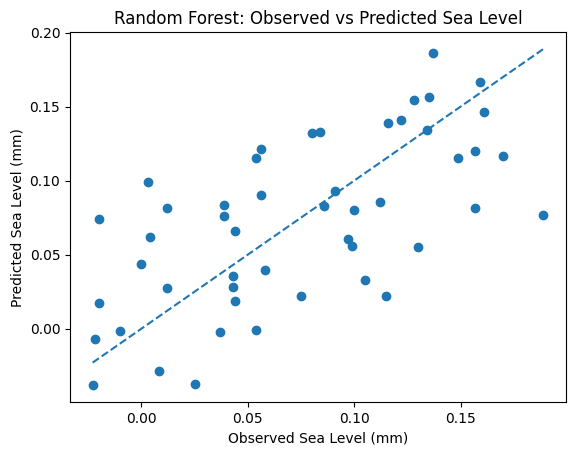


Feature Importance:
Date                              0.267605
Greenland Ice Melt Rates(mass)    0.201193
AMOC                              0.158074
El Nino                           0.120544
CO2                               0.096684
Antarctic Ice Melt Rates(mass)    0.082758
Global Temp Anomaly               0.073142
dtype: float64


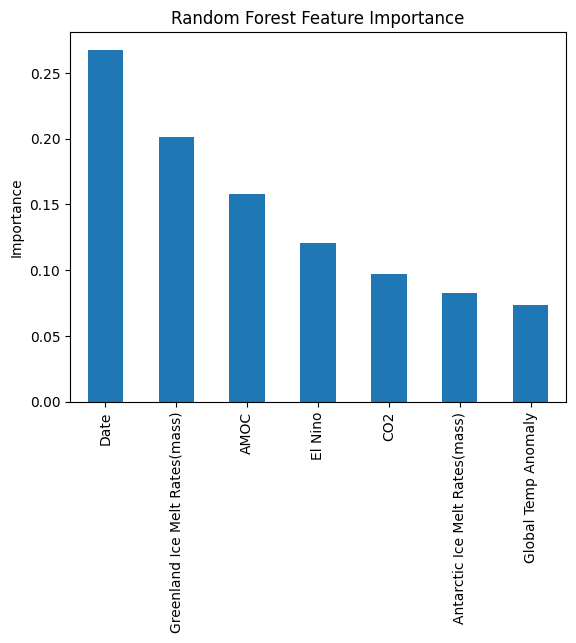

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# ===============================
# 6. Evaluation metrics
# ===============================
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Random Forest Regression Performance")
print("-----------------------------------")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"MAE:        {mae:.4f}")
print(f"R²:         {r2:.4f}")

# ===============================
# 7. Observed vs Predicted Plot
# ===============================
plt.figure()
plt.scatter(y_test, y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Observed Sea Level (mm)")
plt.ylabel("Predicted Sea Level (mm)")
plt.title("Random Forest: Observed vs Predicted Sea Level")
plt.show()

# ===============================
# 8. Feature Importance
# ===============================
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)

feature_importance.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [22]:
y_train.info()
X_train.info()


<class 'pandas.core.series.Series'>
Index: 195 entries, 228 to 102
Series name: Sea Level Monthly Mean
Non-Null Count  Dtype  
--------------  -----  
195 non-null    float64
dtypes: float64(1)
memory usage: 3.0 KB
<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 228 to 102
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            195 non-null    float64
 1   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 2   Greenland Ice Melt Rates(mass)  195 non-null    float64
 3   Global Temp Anomaly             195 non-null    float64
 4   El Nino                         195 non-null    float64
 5   AMOC                            157 non-null    float64
 6   CO2                             195 non-null    float64
dtypes: float64(7)
memory usage: 12.2 KB


Hyperparameter Tuning

In [23]:
df = _rawdata.copy()
target = "Sea Level Monthly Mean"

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

X_train = train_df.drop(columns=[target, "Date"])
y_train = train_df[target]

X_test  = test_df.drop(columns=[target, "Date"])
y_test  = test_df[target]


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])



In [30]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "rf__n_estimators": [300, 500, 800, 1200],
    "rf__max_depth": [None, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15],
    "rf__min_samples_leaf": [1, 2, 4, 6, 8],
    "rf__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Best Parameters: {'rf__n_estimators': 800, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 8, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Best CV RMSE: 0.06464236935886929


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_mse  = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2  = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test MSE:  {test_mse:.4f}")
print(f"Test MAE:   {mae:.4f}")
print(f"Test R²:    {r2:.4f}")


Train RMSE: 0.0450
Test MSE:  0.0056
Test MAE:   0.0598
Test R²:    -0.1749


                          feature  importance
0  Greenland Ice Melt Rates(mass)    0.308860
1                             CO2    0.238309
2  Antarctic Ice Melt Rates(mass)    0.184568
3                            AMOC    0.103686
4             Global Temp Anomaly    0.098603
5                         El Nino    0.065974


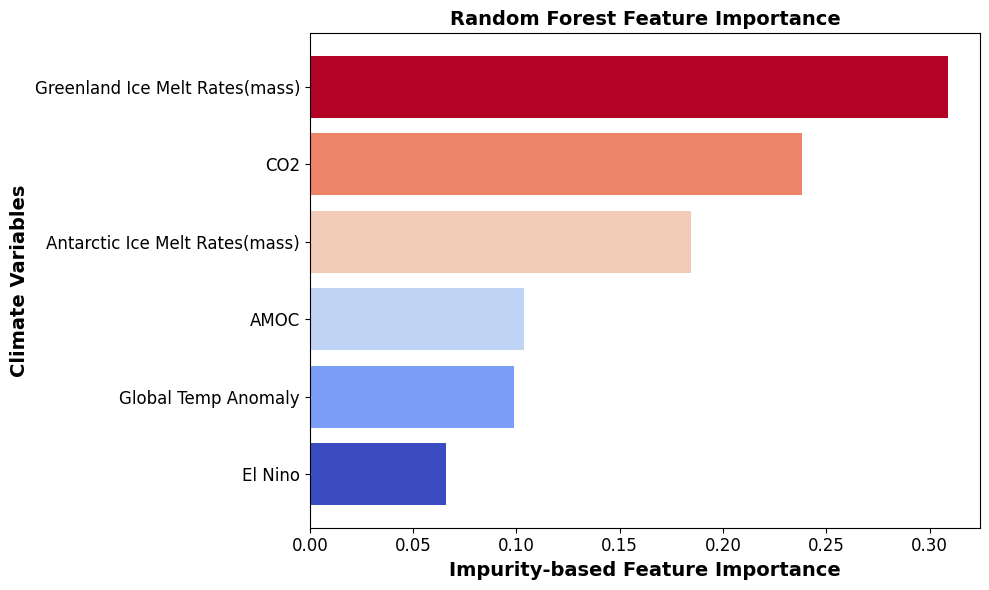

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Grab the fitted Random Forest from the Pipeline
rf = best_model.named_steps["rf"]

# 2) Feature names (columns)
feature_names = X_train.columns

# 3) Impurity-based (aka "Gini") importance
importances = rf.feature_importances_

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

print(imp_df)

# 4) Plot top features
top_n = min(15, len(imp_df))

plt.figure(figsize=(10, 6))

# Create a list of colors (automatically spaced)
#colors = plt.cm.tab20(np.linspace(0, 1, top_n))
colors = plt.cm.coolwarm(np.linspace(0, 1, top_n))
#colors = plt.cm.viridis(np.linspace(0, 1, top_n))
#colors = plt.cm.plasma(np.linspace(0, 1, top_n))


plt.barh(
    imp_df.loc[:top_n-1, "feature"][::-1],
    imp_df.loc[:top_n-1, "importance"][::-1],
    color=colors
)

# Font size controls
plt.xlabel("Impurity-based Feature Importance", fontsize=14, fontweight='bold')
plt.ylabel("Climate Variables", fontsize=14, fontweight='bold')
plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold')

# Optional: control tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()



In [44]:
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if "Times" in font:
        print(font)